# Assignment 2: Build Regression Models

Juan Maldonado Franco  
DDS-8555 Predictive Analysis  
Mohamed Nabeel

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd()
for parent in [ROOT, *ROOT.parents]:
    if (parent / "DDS-8555 - Predictive Analysis").exists():
        COURSE = parent / "DDS-8555 - Predictive Analysis"
        break
else:
    COURSE = ROOT.parents[1]
DATA = COURSE / "data"
KAGGLE = DATA / "kaggle"
SUBMISSIONS = DATA / "submissions"
RANDOM_STATE = 42
pd.set_option("display.max_columns", 80)

## Conceptual Question 3

For the model Salary = 50 + 20GPA + 0.07IQ + 35Level + 0.01(GPA x IQ) - 10(GPA x Level), the college-versus-high-school difference at fixed GPA and IQ is 35 - 10GPA.  Statement iii is correct because college graduates earn more when GPA is below 3.5, the two groups are equal at GPA 3.5, and high school graduates earn more when GPA is above 3.5.  Statement i fails because the education difference is not always positive, statement ii fails because it ignores the GPA x Level interaction, and statement iv fails because the GPA comparison changes with education level.  For GPA = 4.0, IQ = 110, and Level = 1, the substitution is 50 + 20(4.0) + 0.07(110) + 35(1) + 0.01(4.0)(110) - 10(4.0)(1) = 137.1, so the predicted salary is 137.1 thousand dollars.  Part (c) is false: the small numerical coefficient on GPA x IQ does not by itself prove a weak interaction because statistical evidence depends on the t-statistic, which is the coefficient divided by its standard error, not only on the raw coefficient size (James et al., 2023).

In [2]:
gpa = 4.0
iq = 110
level_college = 1
salary = 50 + 20*gpa + 0.07*iq + 35*level_college + 0.01*gpa*iq - 10*gpa*level_college
crossover_gpa = 35 / 10
pd.DataFrame({
    "quantity": ["predicted_salary_thousands", "college_high_school_crossover_gpa"],
    "value": [salary, crossover_gpa],
})

,quantity,value
0,predicted_salary_thousands,137.1
1,college_high_school_crossover_gpa,3.5


## Applied Question 10: Carseats Regression

The Carseats exercise is useful because it forces the model to handle both numeric and qualitative predictors.  Sales is measured in thousands of units, Price is the site price in U.S. dollars, and Urban and US enter as indicator variables.

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.239
Model:                            OLS   Adj. R-squared:                  0.234
Method:                 Least Squares   F-statistic:                     41.52
Date:                Sun, 31 May 2026   Prob (F-statistic):           2.39e-23
Time:                        12:41:42   Log-Likelihood:                -927.66
No. Observations:                 400   AIC:                             1863.
Df Residuals:                     396   BIC:                             1879.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       13.0435      0.651     20.036   

,part,answer
0,(a) Full model,Fit Sales ~ Price + Urban + US.
1,(b) Coefficient interpretation,Intercept=13.043 thousand units when all predi...
2,(c) Full fitted equation,Sales = 13.043 - 0.0545(Price) - 0.022I(Urban=...
3,(d) Rejected H0 terms,Reject H0: beta_j=0 for Price (p=1.61e-22) and...
4,(e) Smaller model,Fit Sales ~ Price + US.
5,(f) Fit comparison,"Full R2=0.239, adj R2=0.234, AIC=1863.3, BIC=1..."
6,(g) 95 percent confidence intervals,"Price CI [-0.0648, -0.0442] is strictly negati..."
7,(h) Outliers and leverage,"Checked leverage with the 2p/n rule, externall..."


,lower_95,upper_95
Intercept,11.79032,14.271265
US[T.Yes],0.69152,1.707766
Price,-0.06476,-0.044195


,term,vif
0,Intercept,26.115860
1,US[T.Yes],1.003359
2,Price,1.003359


,rule,threshold,count,maximum
0,high leverage,> 2p/n = 0.015,20,0.043338
1,large studentized residual,> |3|,0,2.891521
2,large Cook's distance,> 4/n = 0.010,19,0.026109


,assumption_or_check,evidence
0,Linearity / constant variance,Breusch-Pagan p=0.085; residual plot inspected
1,Independence of errors,Durbin-Watson=1.912
2,Residual distribution,Jarque-Bera p=0.688; Q-Q plot inspected
3,Collinearity,Maximum non-intercept VIF=1.003
4,Outliers,Max absolute externally studentized residual=2...
5,Influential observations,Max leverage=0.043; max Cook's D=0.026; Cook's...
6,Model parsimony,Full R2=0.239; smaller R2=0.239


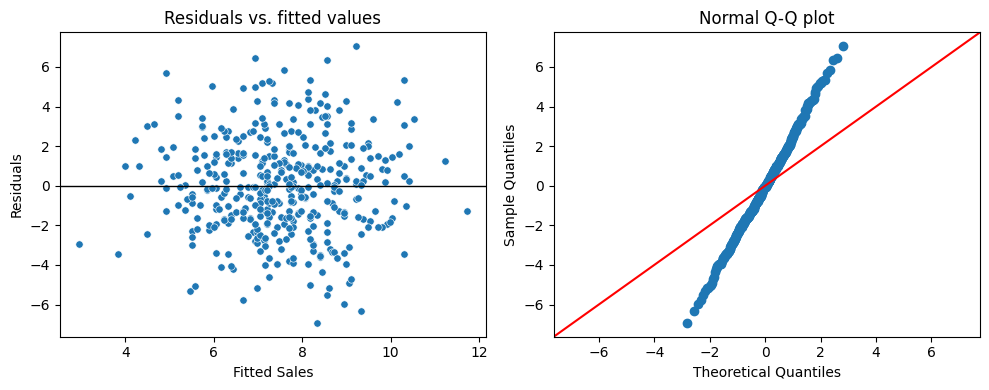

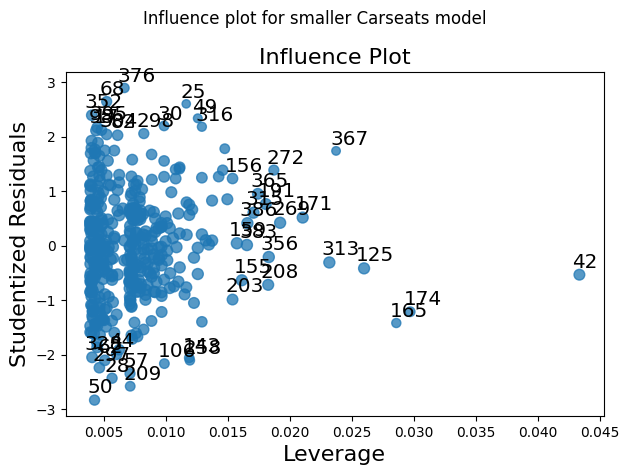

In [3]:
from ISLP import load_data
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson
from scipy import stats

carseats = load_data("Carseats")
model_full = smf.ols("Sales ~ Price + Urban + US", data=carseats).fit()
model_small = smf.ols("Sales ~ Price + US", data=carseats).fit()

print(model_full.summary())
print("\nSmaller model")
print(model_small.summary())

print("\nApplied Question 10 visible checklist")
ci = model_small.conf_int()
ci.columns = ["lower_95", "upper_95"]
price_coef = model_small.params["Price"]
us_coef = model_small.params["US[T.Yes]"]
full_params = model_full.params
full_pvalues = model_full.pvalues
full_rse = np.sqrt(model_full.mse_resid)
small_rse = np.sqrt(model_small.mse_resid)
partial_f = model_full.compare_f_test(model_small)
urban_coef = full_params["Urban[T.Yes]"]
full_equation = (
    f"Sales = {full_params['Intercept']:.3f} "
    f"{'-' if full_params['Price'] < 0 else '+'} {abs(full_params['Price']):.4f}(Price) "
    f"{'-' if urban_coef < 0 else '+'} {abs(urban_coef):.3f}I(Urban=Yes) "
    f"{'-' if full_params['US[T.Yes]'] < 0 else '+'} {abs(full_params['US[T.Yes]']):.3f}I(US=Yes) + epsilon."
)
display(pd.DataFrame({
    "part": [
        "(a) Full model",
        "(b) Coefficient interpretation",
        "(c) Full fitted equation",
        "(d) Rejected H0 terms",
        "(e) Smaller model",
        "(f) Fit comparison",
        "(g) 95 percent confidence intervals",
        "(h) Outliers and leverage",
    ],
    "answer": [
        "Fit Sales ~ Price + Urban + US.",
        f"Intercept={full_params['Intercept']:.3f} thousand units when all predictors are zero; Price={full_params['Price']:.4f} thousand fewer units per dollar; Urban={urban_coef:.3f} thousand units relative to nonurban stores; US={full_params['US[T.Yes]']:.3f} thousand more units relative to non-US stores.",
        full_equation,
        f"Reject H0: beta_j=0 for Price (p={full_pvalues['Price']:.3g}) and US (p={full_pvalues['US[T.Yes]']:.3g}); fail to reject Urban (p={full_pvalues['Urban[T.Yes]']:.3g}).",
        "Fit Sales ~ Price + US.",
        f"Full R2={model_full.rsquared:.3f}, adj R2={model_full.rsquared_adj:.3f}, AIC={model_full.aic:.1f}, BIC={model_full.bic:.1f}, RSE={full_rse:.3f}; smaller R2={model_small.rsquared:.3f}, adj R2={model_small.rsquared_adj:.3f}, AIC={model_small.aic:.1f}, BIC={model_small.bic:.1f}, RSE={small_rse:.3f}; nested F-test p={partial_f[1]:.3f}.",
        f"Price CI [{ci.loc['Price','lower_95']:.4f}, {ci.loc['Price','upper_95']:.4f}] is strictly negative; US CI [{ci.loc['US[T.Yes]','lower_95']:.3f}, {ci.loc['US[T.Yes]','upper_95']:.3f}] excludes zero.",
        "Checked leverage with the 2p/n rule, externally studentized residuals with |t*| > 3, Cook's distance with 4/n, and an influence plot.",
    ],
}))
display(ci)

vif = pd.DataFrame({
    "term": model_small.model.exog_names,
    "vif": [variance_inflation_factor(model_small.model.exog, i) for i in range(model_small.model.exog.shape[1])],
})
display(vif)

influence = model_small.get_influence()
studentized = influence.resid_studentized_external
cooks = influence.cooks_distance[0]
leverage = influence.hat_matrix_diag
n_obs = int(model_small.nobs)
n_params = int(model_small.df_model + 1)
leverage_rule = 2 * n_params / n_obs
cooks_rule = 4 / n_obs
bp_f_pvalue = het_breuschpagan(model_small.resid, model_small.model.exog)[3]
influence_flags = pd.DataFrame({
    "rule": ["high leverage", "large studentized residual", "large Cook's distance"],
    "threshold": [f"> 2p/n = {leverage_rule:.3f}", "> |3|", f"> 4/n = {cooks_rule:.3f}"],
    "count": [
        int((leverage > leverage_rule).sum()),
        int((np.abs(studentized) > 3).sum()),
        int((cooks > cooks_rule).sum()),
    ],
    "maximum": [leverage.max(), np.max(np.abs(studentized)), cooks.max()],
})
display(influence_flags)
diag = pd.DataFrame({
    "assumption_or_check": [
        "Linearity / constant variance",
        "Independence of errors",
        "Residual distribution",
        "Collinearity",
        "Outliers",
        "Influential observations",
        "Model parsimony",
    ],
    "evidence": [
        f"Breusch-Pagan p={bp_f_pvalue:.3f}; residual plot inspected",
        f"Durbin-Watson={durbin_watson(model_small.resid):.3f}",
        f"Jarque-Bera p={stats.jarque_bera(model_small.resid).pvalue:.3f}; Q-Q plot inspected",
        f"Maximum non-intercept VIF={vif.loc[vif.term != 'Intercept', 'vif'].max():.3f}",
        f"Max absolute externally studentized residual={np.max(np.abs(studentized)):.3f}; count above 3={(np.abs(studentized) > 3).sum()}",
        f"Max leverage={leverage.max():.3f}; max Cook's D={cooks.max():.3f}; Cook's count above 4/n={(cooks > cooks_rule).sum()}",
        f"Full R2={model_full.rsquared:.3f}; smaller R2={model_small.rsquared:.3f}",
    ],
})
display(diag)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.scatterplot(x=model_small.fittedvalues, y=model_small.resid, ax=axes[0], s=28)
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title("Residuals vs. fitted values")
axes[0].set_xlabel("Fitted Sales")
axes[0].set_ylabel("Residuals")
sm.qqplot(model_small.resid, line="45", ax=axes[1])
axes[1].set_title("Normal Q-Q plot")
plt.tight_layout()

fig = sm.graphics.influence_plot(model_small, criterion="cooks", size=6)
fig.suptitle("Influence plot for smaller Carseats model")
plt.tight_layout()

The full model shows that Price and US are statistically meaningful, while Urban is not.  The fitted full equation is Sales = 13.043 - 0.0545(Price) - 0.022I(Urban = Yes) + 1.201I(US = Yes) + epsilon.  The intercept is a mathematical baseline rather than a realistic store condition because a zero-dollar price is outside the practical range.  The Price coefficient means expected sales decrease by about 0.0545 thousand units for each one-dollar increase in price, holding Urban and US constant.  The Urban coefficient is near zero and has p = .936, so the analysis fails to reject H0 for Urban.  The US coefficient means stores in the United States are expected to sell about 1.2 thousand more units than non-US stores at the same price and Urban status.  The smaller model keeps Price and US because those predictors have evidence of association with Sales, and removing Urban leaves R2 essentially unchanged.  The 95 percent confidence intervals for Price and US exclude zero, which supports rejecting H0: beta_j = 0 for those predictors.  The diagnostics support a cautious interpretation: Durbin-Watson is close to 2, VIF values are low, the Jarque-Bera and Q-Q checks do not show severe residual non-normality, and the leverage, studentized residual, Cook's distance, and influence-plot checks do not suggest that a small number of observations controls the conclusion.  The low R2 still matters because the model explains only part of sales variation, so it is better for directional interpretation than for complete forecasting.

## Kaggle Regression with Abalone

Two Kaggle submissions were made for the Abalone regression competition: a ridge regression baseline and a random forest regression model.  The notebook keeps local validation separate from Kaggle scoring so the interpretation is not based only on the public leaderboard.  Ridge is used as a regularized linear benchmark, while random forest is used as a nonlinear ensemble benchmark that can capture interactions among abalone measurements.  The abalone task is substantively appropriate because age is traditionally inferred from shell rings, while the competition asks whether easier physical measurements can predict that outcome (Nash et al., 1994).

,statistic,Rings
0,count,90615.000000
1,mean,9.696794
2,median,9.000000
3,std,3.176221
4,skew,1.204273
5,minimum,1.000000
6,maximum,29.000000


,model,validation_rmsle
2,Random forest,0.153956
1,Ridge,0.165662
0,Mean baseline,0.290949


,feature,ridge_coefficient,abs_coefficient
7,num__Whole weight.1,-3.205521,3.205521
9,num__Shell weight,2.736675,2.736675
6,num__Whole weight,1.667539,1.667539
4,num__Diameter,0.770400,0.770400
5,num__Height,0.761186,0.761186
8,num__Whole weight.2,-0.681751,0.681751
1,cat__Sex_I,-0.468415,0.468415
0,cat__Sex_F,0.245529,0.245529
2,cat__Sex_M,0.222886,0.222886
3,num__Length,-0.208276,0.208276


,feature,importance
9,num__Shell weight,0.631845
7,num__Whole weight.1,0.141895
6,num__Whole weight,0.066712
8,num__Whole weight.2,0.051853
3,num__Length,0.033946
5,num__Height,0.030749
4,num__Diameter,0.028302
1,cat__Sex_I,0.007147
0,cat__Sex_F,0.003832
2,cat__Sex_M,0.003718


,model,submission_file,generated_rows,generated_columns,submitted_file_exists,submitted_rows,submitted_columns,ready_to_write_with_to_csv
0,Ridge,A2_ridge_playground_series_s4e4.csv,60411,"id, Rings",True,60411,"id, Rings",True
1,Random forest,A2_random_forest_playground_series_s4e4.csv,60411,"id, Rings",True,60411,"id, Rings",True


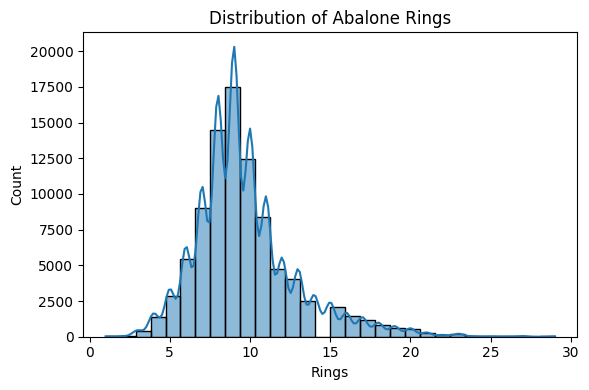

In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_log_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.base import clone

abalone = pd.read_csv(KAGGLE / "playground-series-s4e4" / "train.csv")
X = abalone.drop(columns=["Rings"])
y = abalone["Rings"]
cat = ["Sex"]
num = [c for c in X.columns if c not in cat + ["id"]]
pre = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat),
    ("num", StandardScaler(), num),
], remainder="drop")
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=.2, random_state=RANDOM_STATE)
display(pd.DataFrame({
    "statistic": ["count", "mean", "median", "std", "skew", "minimum", "maximum"],
    "Rings": [y.count(), y.mean(), y.median(), y.std(), y.skew(), y.min(), y.max()],
}))

fig, ax = plt.subplots(figsize=(6, 4))
sns.histplot(y, bins=30, kde=True, ax=ax)
ax.set_title("Distribution of Abalone Rings")
ax.set_xlabel("Rings")
plt.tight_layout()

models = {
    "Ridge": Pipeline([("pre", pre), ("model", Ridge(alpha=10.0))]),
    "Random forest": Pipeline([("pre", pre), ("model", RandomForestRegressor(n_estimators=120, min_samples_leaf=3, random_state=RANDOM_STATE, n_jobs=-1))]),
}
baseline_pred = np.repeat(y_train.mean(), len(y_valid))
rows = [{"model": "Mean baseline", "validation_rmsle": np.sqrt(mean_squared_log_error(y_valid, baseline_pred))}]
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = np.maximum(model.predict(X_valid), 1)
    rows.append({"model": name, "validation_rmsle": np.sqrt(mean_squared_log_error(y_valid, pred))})
validation_results = pd.DataFrame(rows).sort_values("validation_rmsle")
display(validation_results)

feature_names = models["Ridge"].named_steps["pre"].get_feature_names_out()
ridge_weights = pd.DataFrame({
    "feature": feature_names,
    "ridge_coefficient": models["Ridge"].named_steps["model"].coef_,
})
ridge_weights["abs_coefficient"] = ridge_weights["ridge_coefficient"].abs()
display(ridge_weights.sort_values("abs_coefficient", ascending=False).head(10))

rf_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": models["Random forest"].named_steps["model"].feature_importances_,
}).sort_values("importance", ascending=False)
display(rf_importance.head(10))

test = pd.read_csv(KAGGLE / "playground-series-s4e4" / "test.csv")
submission_rows = []
for name, model, filename in [
    ("Ridge", models["Ridge"], "A2_ridge_playground_series_s4e4.csv"),
    ("Random forest", models["Random forest"], "A2_random_forest_playground_series_s4e4.csv"),
]:
    full_model = clone(model).fit(X, y)
    submission = pd.DataFrame({
        "id": test["id"],
        "Rings": np.maximum(full_model.predict(test), 1),
    })
    path = SUBMISSIONS / filename
    existing = pd.read_csv(path)
    submission_rows.append({
        "model": name,
        "submission_file": filename,
        "generated_rows": len(submission),
        "generated_columns": ", ".join(submission.columns),
        "submitted_file_exists": path.exists(),
        "submitted_rows": len(existing),
        "submitted_columns": ", ".join(existing.columns),
        "ready_to_write_with_to_csv": True,
    })
display(pd.DataFrame(submission_rows))

,feature,vif
1,Diameter,959.988285
0,Length,895.831782
3,Whole weight,271.722902
2,Height,99.990913
4,Whole weight.1,80.573934
5,Whole weight.2,75.887621
6,Shell weight,71.367188


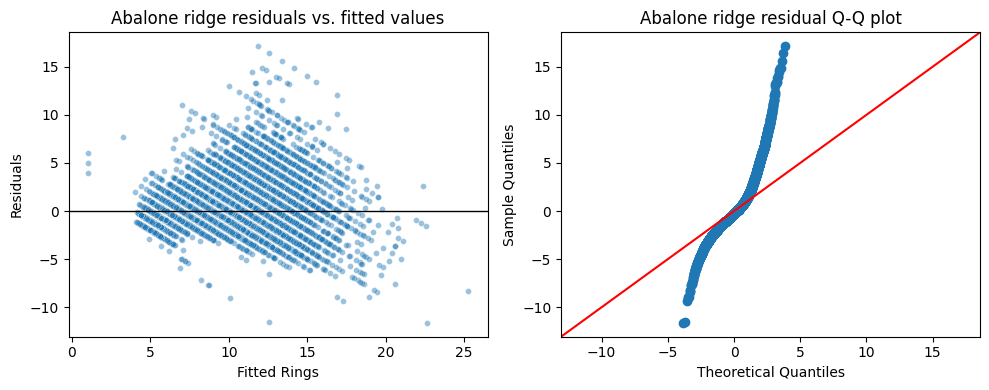

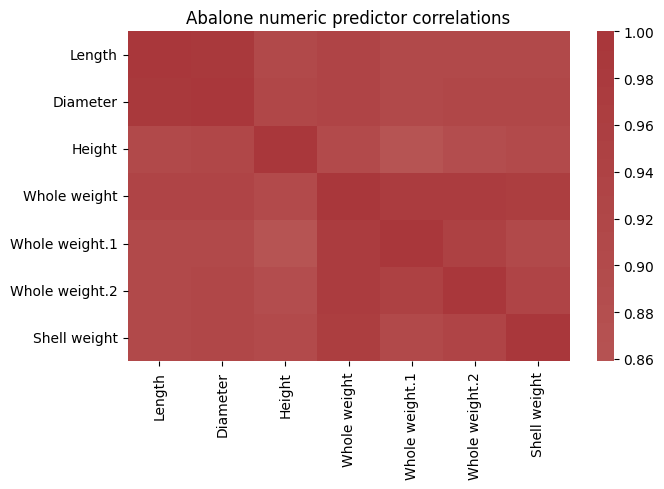

In [5]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

abalone_numeric = X_train[num].copy()
abalone_vif = pd.DataFrame({
    "feature": num,
    "vif": [variance_inflation_factor(abalone_numeric.values, i) for i in range(abalone_numeric.shape[1])],
}).sort_values("vif", ascending=False)
display(abalone_vif)

ridge_pred = np.maximum(models["Ridge"].predict(X_valid), 1)
ridge_resid = y_valid - ridge_pred
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.scatterplot(x=ridge_pred, y=ridge_resid, s=18, alpha=.45, ax=axes[0])
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title("Abalone ridge residuals vs. fitted values")
axes[0].set_xlabel("Fitted Rings")
axes[0].set_ylabel("Residuals")
sm.qqplot(ridge_resid, line="45", ax=axes[1])
axes[1].set_title("Abalone ridge residual Q-Q plot")
plt.tight_layout()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(abalone_numeric.corr(), cmap="vlag", center=0, ax=ax)
ax.set_title("Abalone numeric predictor correlations")
plt.tight_layout()

In [6]:
import re

status_path = SUBMISSIONS / "kaggle_submission_status_playground-series-s4e4.txt"
for encoding in ("utf-16", "utf-8"):
    try:
        text = status_path.read_text(encoding=encoding)
        break
    except UnicodeError:
        continue

records = []
current = {}
for line in text.splitlines():
    if not line.strip():
        continue
    if "ref" in line and "fileName" in line:
        continue
    if re.match(r"^\d+", line.strip()):
        if current:
            records.append(current)
        parts = re.split(r"\s{2,}", line.strip())
        if len(parts) >= 7:
            current = {
                "ref": parts[0],
                "fileName": parts[1],
                "date": parts[2],
                "description": parts[3],
                "status": parts[4],
                "publicScore": parts[5],
                "privateScore": parts[6],
            }
    elif current and "A2_" in current.get("fileName", ""):
        current["description"] = (current.get("description", "") + " " + line.strip()).strip()
if current:
    records.append(current)

a2_records = pd.DataFrame([row for row in records if "A2_" in row.get("fileName", "")])
display(a2_records)
display(pd.DataFrame({
    "submission_file": [
        "A2_ridge_playground_series_s4e4.csv",
        "A2_random_forest_playground_series_s4e4.csv",
    ],
    "exists_locally": [
        (SUBMISSIONS / "A2_ridge_playground_series_s4e4.csv").exists(),
        (SUBMISSIONS / "A2_random_forest_playground_series_s4e4.csv").exists(),
    ],
}))
display(pd.DataFrame({
    "evidence": ["Public GitHub repository", "Notebook path in repository"],
    "value": [
        "https://github.com/maldo81/dds-8555-predictive-analysis",
        "Week 2/Assignment 2/MaldonadoJDDS8555-2.ipynb",
    ],
}))

,ref,fileName,date,description,status,publicScore,privateScore
0,52966788,A2_random_forest_playground_series_s4e4.csv,2026-05-23 21:27:11.893000,DDS-8555 A2 random forest regression,SubmissionStatus.COMPLETE,0.14927,0.14943
1,52966787,A2_ridge_playground_series_s4e4.csv,2026-05-23 21:27:09.197000,DDS-8555 A2 ridge regression baseline,SubmissionStatus.COMPLETE,0.16442,0.16372


,submission_file,exists_locally
0,A2_ridge_playground_series_s4e4.csv,True
1,A2_random_forest_playground_series_s4e4.csv,True


,evidence,value
0,Public GitHub repository,https://github.com/maldo81/dds-8555-predictive...
1,Notebook path in repository,Week 2/Assignment 2/MaldonadoJDDS8555-2.ipynb


## Interpretation

The ridge model provides a stable linear benchmark, while the random forest can capture interactions and nonlinear structure without manually specifying every term.  The validation results and Kaggle scores both favored the random forest submission, which strengthens the case that the abalone measurements contain nonlinear signal.  The Abalone VIF table shows why a regularized baseline is sensible: shell size and weight measurements carry overlapping information, so shrinkage helps stabilize the linear benchmark.  Regression assumptions are most directly relevant to the linear models: the Carseats analysis checks linearity and constant variance through residual structure, independence through Durbin-Watson, collinearity through VIF, and residual shape through Jarque-Bera and Q-Q diagnostics.  The random forest relaxes the linearity and normal-residual assumptions, but it still requires held-out validation because flexibility can hide overfitting.  The practical finding is therefore split: the simpler regression is useful for explaining directional effects, while the random forest is the better submission model for this prediction task.

The Abalone competition uses RMSLE, so errors are evaluated on the log scale.  This penalizes proportional error and helps keep large-ring observations from dominating the evaluation as strongly as they would under RMSE.  Rings is right-skewed in the training data, with skew about 1.20, so this metric is a reasonable fit for a positive count target.  The mean baseline RMSLE was about 0.291, ridge improved validation RMSLE to about 0.166, and random forest improved it further to about 0.154.  The ridge coefficient table gives a regularized direction-of-effect view after preprocessing, while the random forest importance table shows that nonlinear prediction is driven mainly by physical size and weight measures.  The notebook refits both models on the full training data and writes the two A2 submission CSV files before showing the Kaggle completion evidence, which links the displayed code to the submitted artifacts.

## References

James, G., Witten, D., Hastie, T., Tibshirani, R., & Taylor, J. (2023). *An introduction to statistical learning: With applications in Python*.  Springer. https://doi.org/10.1007/978-3-031-38747-0

Nash, W.  J., Sellers, T.  L., Talbot, S.  R., Cawthorn, A.  J., & Ford, W.  B. (1994). *The population biology of abalone (Haliotis species) in Tasmania.  I.  Blacklip abalone (H. rubra) from the north coast and islands of Bass Strait* (Technical Report No.  48).  Sea Fisheries Division.

Snee, R.  D. (1977).  Validation of regression models: Methods and examples. *Technometrics, 19*(4), 415-428. https://doi.org/10.1080/00401706.1977.10489581